# ⚡ ml-evaluator — Demo Notebook

> Turn model evaluation from a chore into a single function call.

This notebook walks through **every feature** of `ml-evaluator` v1.3 step by step:

| Section | What you'll learn |
|---------|------------------|
| 1 · Setup | Install & import, build a demo dataset |
| 2 · Single Model | `metrics`, `interpret`, `classification_report`, all plots |
| 3 · model_summary | Full 2×2 dashboard in one call |
| 4 · Bias–Variance | `bv_stats`, `plot_learning_curve`, `bias_variance` |
| 5 · Multi-Model | All comparison functions & dashboards |
| 6 · Result Object | How to access returned data programmatically |
| 7 · Save Figures | Exporting plots to disk |

---
## 1 · Setup

In [1]:
# Install the library (run once)
!pip install ml-evaluator --quiet

In [2]:
import ml_evaluator as ev

# ── Scikit-learn helpers ──────────────────────────────────────────────
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

print("✅ All imports successful")

✅ All imports successful


### 1.1 · Build a realistic binary classification dataset

We'll use `make_classification` to generate a **1 000-sample, 10-feature** dataset — balanced classes, some noise — which gives models realistic (non-perfect) scores to evaluate.

In [3]:
X, y = make_classification(
    n_samples=1_000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    weights=[0.5, 0.5],   # balanced classes
    flip_y=0.05,          # 5% label noise → realistic scores
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Class distribution (test) — 0: {(y_test==0).sum()}  1: {(y_test==1).sum()}")

Train: (800, 10)  |  Test: (200, 10)
Class distribution (test) — 0: 100  1: 100


### 1.2 · Train a Random Forest (our main single-model)

Throughout Sections 2–4 we'll evaluate **this one model** in depth.

In [4]:
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf.fit(X_train, y_train)

print(f"Train accuracy : {rf.score(X_train, y_train):.4f}")
print(f"Test  accuracy : {rf.score(X_test,  y_test):.4f}")

Train accuracy : 1.0000
Test  accuracy : 0.9100


---
## 2 · Single-Model Evaluation

The single-model module gives you **granular control** — each aspect of evaluation has its own function.

### 2.1 · `ev.metrics()` — raw numbers

Computes **Accuracy, F1, Precision, Recall, ROC-AUC** and prints them automatically.  
Also returns a `Result` object so you can access each value programmatically.

```
ev.metrics(model, X_test, y_test, *, model_name="Model", verbose=True)
→ Result
```

In [5]:
m = ev.metrics(rf, X_test, y_test, model_name="Random Forest")


  Model Summary — Random Forest
  Accuracy  : 0.9100
  F1        : 0.9109
  Precision : 0.9020
  Recall    : 0.9200
  ROC-AUC   : 0.9390



In [6]:
# Access individual values from the returned Result object
print("Accuracy  :", round(m["accuracy"],  4))
print("F1        :", round(m["f1"],        4))
print("Precision :", round(m["precision"], 4))
print("Recall    :", round(m["recall"],    4))
print("ROC-AUC   :", round(m["roc_auc"],  4))

# Available keys: accuracy · f1 · precision · recall · roc_auc
#                 y_pred  · y_prob · report

Accuracy  : 0.91
F1        : 0.9109
Precision : 0.902
Recall    : 0.92
ROC-AUC   : 0.939


### 2.2 · `ev.interpret()` — plain-English explanation

Translates the numbers into human-readable judgements.  
Returns `Result` with a single `"text"` key.

```
ev.interpret(model, X_test, y_test, *, model_name="Model", verbose=True)
→ Result
```

In [7]:
interp = ev.interpret(rf, X_test, y_test, model_name="Random Forest")


  Interpretation — Random Forest
  ─────────────────────────────────────────────────────
  ✅  Accuracy 0.910 — high overall correctness.
  ✅  F1 0.911 — strong balance between precision and recall.
  ✅  Precision (0.902) ≈ Recall (0.920) — well balanced.
       AUC = 0.939 — Good. Works well but there is room to improve.



### 2.3 · `ev.classification_report()` — per-class breakdown

Prints a formatted Precision / Recall / F1 table for every class.

```
ev.classification_report(model, X_test, y_test, *, model_name, class_labels)
→ None
```

In [8]:
ev.classification_report(
    rf, X_test, y_test,
    model_name="Random Forest",
    class_labels=["Negative", "Positive"]
)


  Classification Report — Random Forest
  ────────────────────────────────────────────────────────
  Class            Precision   Recall  F1-Score  Support
  ────────────────────────────────────────────────────────
  Negative             0.918    0.900     0.909      100
  Positive             0.902    0.920     0.911      100
  ────────────────────────────────────────────────────────
  Accuracy                                0.910      200
  macro avg            0.910    0.910     0.910
  weighted avg         0.910    0.910     0.910



### 2.4 · `ev.plot_confusion_matrix()` — visualise TP / FP / FN / TN

```
ev.plot_confusion_matrix(model, X_test, y_test, *, model_name, class_labels, color, figsize, save_path)
→ None
```

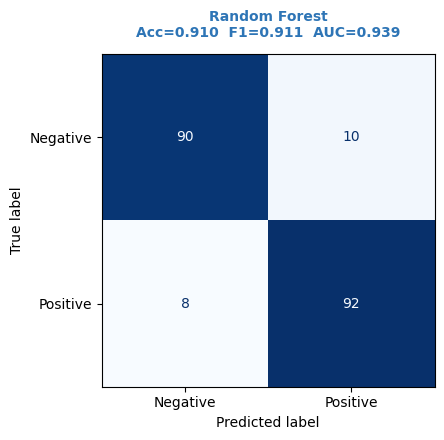

In [9]:
ev.plot_confusion_matrix(
    rf, X_test, y_test,
    model_name="Random Forest",
    class_labels=["Negative", "Positive"],
    color="#2E75B6"
)

### 2.5 · `ev.plot_roc_curve()` — AUC with interpretation

Plots the ROC curve with a filled area and an **AUC grade box**:
≥ 0.95 Excellent · ≥ 0.85 Good · ≥ 0.70 Fair · < 0.70 Poor

> ⚠️ Requires the model to support `predict_proba`.

```
ev.plot_roc_curve(model, X_test, y_test, *, model_name, color, figsize, save_path)
→ None
```


  ROC-AUC (Random Forest): 0.9390
  AUC = 0.939 — Good. Works well but there is room to improve.



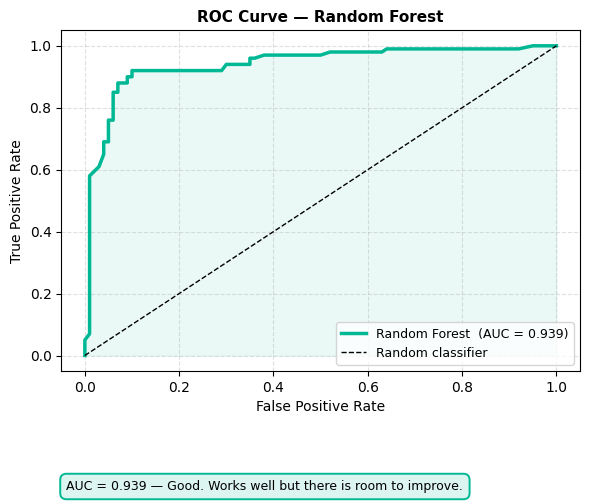

In [10]:
ev.plot_roc_curve(
    rf, X_test, y_test,
    model_name="Random Forest",
    color="#00b894"
)

### 2.6 · `ev.plot_metrics_bar()` — bar chart with baseline

Bar chart of all five metrics with a **0.5 random-baseline line** drawn for context.

```
ev.plot_metrics_bar(model, X_test, y_test, *, model_name, color, figsize, save_path)
→ None
```

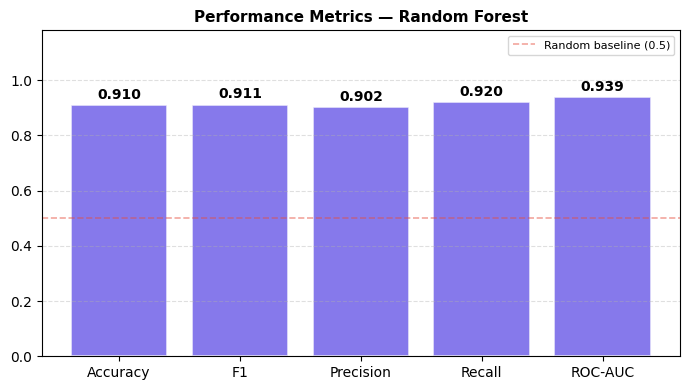

In [11]:
ev.plot_metrics_bar(
    rf, X_test, y_test,
    model_name="Random Forest",
    color="#6c5ce7"
)

---
## 3 · `ev.model_summary()` — Full 2×2 Dashboard

Combines **all four views** into one figure and also prints metrics + interpretation to the terminal. The go-to function when you want the complete picture in a single call.

```
┌─────────────────────┬─────────────────────┐
│  A · Confusion Mat. │  B · ROC Curve      │
├─────────────────────┼─────────────────────┤
│  C · Metrics Bar    │  D · Class. Report  │
└─────────────────────┴─────────────────────┘
```

```
ev.model_summary(model, X_test, y_test, *, model_name, class_labels, color, figsize, save_path)
→ None
```


  Model Summary — Random Forest
  Accuracy  : 0.9100
  F1        : 0.9109
  Precision : 0.9020
  Recall    : 0.9200
  ROC-AUC   : 0.9390

  Interpretation — Random Forest
  ─────────────────────────────────────────────────────
  ✅  Accuracy 0.910 — high overall correctness.
  ✅  F1 0.911 — strong balance between precision and recall.
  ✅  Precision (0.902) ≈ Recall (0.920) — well balanced.
       AUC = 0.939 — Good. Works well but there is room to improve.



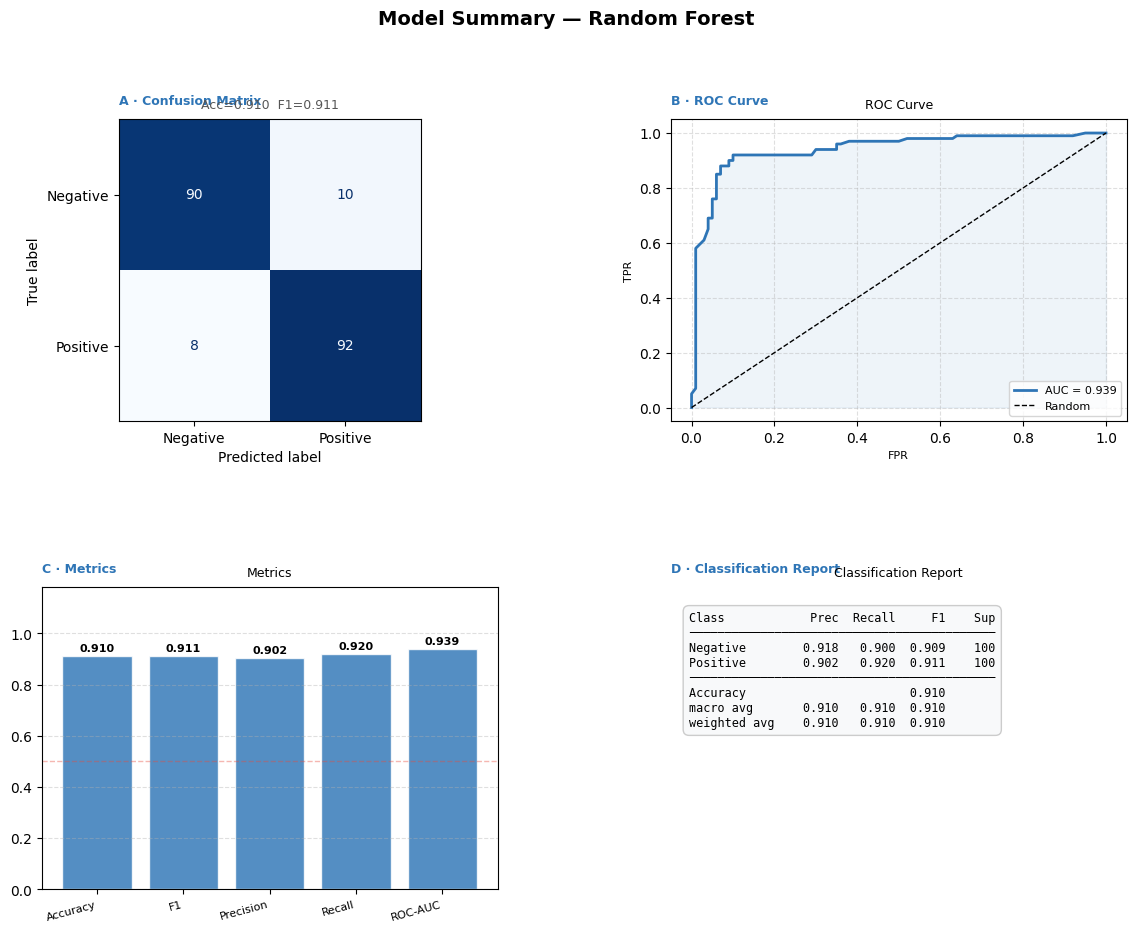

In [12]:
ev.model_summary(
    rf, X_test, y_test,
    model_name="Random Forest",
    class_labels=["Negative", "Positive"],
    color="#2E75B6"
)

---
## 4 · Bias–Variance Analysis

Diagnose whether your model is **Overfitting**, **Underfitting**, or a **Good Fit** using cross-validated learning curves.

| Diagnosis | Condition |
|-----------|----------|
| 🟢 Good Fit | gap ≤ overfit_threshold AND val_error ≤ high_bias_threshold |
| 🔴 Overfitting | train_acc − val_acc > `overfit_threshold` (default 0.10) |
| 🔵 Underfitting | val error rate > `high_bias_threshold` (default 0.15) |

### 4.1 · `ev.bv_stats()` — numbers only, no plot

```
ev.bv_stats(model, X_train, y_train, *, n_splits, overfit_threshold, high_bias_threshold, ...)
→ Result  (keys: mean_train · mean_val · gap · bias_proxy · val_std · diagnosis · explanation)
```

In [13]:
bv = ev.bv_stats(
    rf, X_train, y_train,
    model_name="Random Forest",
    n_splits=5,
    overfit_threshold=0.10,
    high_bias_threshold=0.15
)


  🔴 Random Forest
     Train Acc : 1.0000
     Val   Acc : 0.8662
     Gap       : 0.1338   (threshold: 0.1)
     Val Std   : 0.0239   (variance proxy)
     Diagnosis : Overfit
     Train–val gap is 0.134 (>0.1). The model memorises training data but fails to generalise.
→ Try: regularisation, reduce model complexity, more training data, dropout.


In [14]:
# Access results programmatically
print("Diagnosis  :", bv["diagnosis"])
print("Explanation:", bv["explanation"])
print(f"Train acc  : {bv['mean_train']:.4f}")
print(f"Val acc    : {bv['mean_val']:.4f}")
print(f"Gap        : {bv['gap']:.4f}")

Diagnosis  : Overfit
Explanation: Train–val gap is 0.134 (>0.1). The model memorises training data but fails to generalise.
→ Try: regularisation, reduce model complexity, more training data, dropout.
Train acc  : 1.0000
Val acc    : 0.8662
Gap        : 0.1338


### 4.2 · `ev.plot_learning_curve()` — visual diagnosis

Learning curve with ±1 std shading, gap annotation, and a **diagnosis box**.

```
ev.plot_learning_curve(model, X_train, y_train, *, color, figsize, ...)
→ None
```

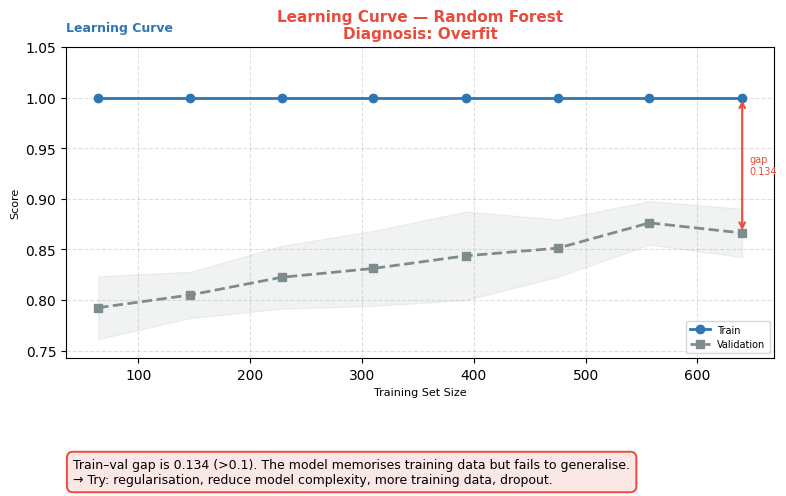

In [15]:
ev.plot_learning_curve(
    rf, X_train, y_train,
    model_name="Random Forest",
    color="#2E75B6"
)

### 4.3 · `ev.bias_variance()` — stats + plot in one call

Equivalent to calling `bv_stats()` followed by `plot_learning_curve()`.  
Returns the same `Result` as `bv_stats()`.

```
ev.bias_variance(model, X_train, y_train, ...)  →  Result
```


  🔴 Random Forest
     Train Acc : 1.0000
     Val   Acc : 0.8662
     Gap       : 0.1338   (threshold: 0.1)
     Val Std   : 0.0239   (variance proxy)
     Diagnosis : Overfit
     Train–val gap is 0.134 (>0.1). The model memorises training data but fails to generalise.
→ Try: regularisation, reduce model complexity, more training data, dropout.


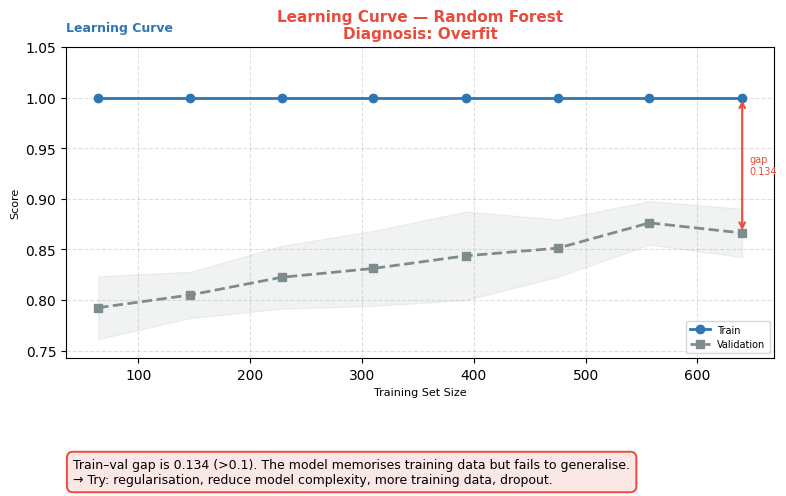


Diagnosis: Overfit


In [16]:
bv_full = ev.bias_variance(
    rf, X_train, y_train,
    model_name="Random Forest"
)

print("\nDiagnosis:", bv_full["diagnosis"])

#### 💡 Demonstrating Overfitting & Underfitting

We'll intentionally create two edge-case models to show what different diagnoses look like.

=== Overfitting Model ===

  🔴 Deep Decision Tree
     Train Acc : 1.0000
     Val   Acc : 0.7812
     Gap       : 0.2188   (threshold: 0.1)
     Val Std   : 0.0435   (variance proxy)
     Diagnosis : Overfit
     Train–val gap is 0.219 (>0.1). The model memorises training data but fails to generalise.
→ Try: regularisation, reduce model complexity, more training data, dropout.


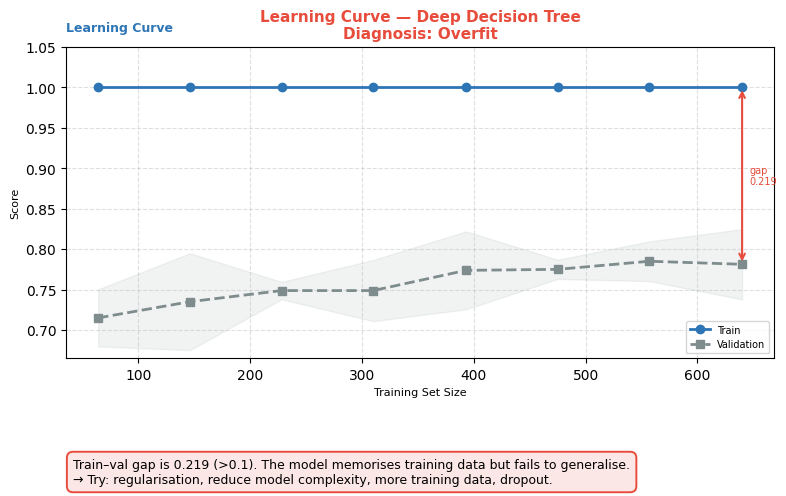

In [17]:
# --- Overfitting model: deep tree with no regularisation ---
overfit_model = DecisionTreeClassifier(max_depth=None, random_state=42)
overfit_model.fit(X_train, y_train)

print("=== Overfitting Model ===")
ev.bias_variance(overfit_model, X_train, y_train, model_name="Deep Decision Tree")

=== Underfitting Model ===

  ⚠️  Shallow Decision Tree (depth=1)
     Train Acc : 0.7863
     Val   Acc : 0.7662
     Gap       : 0.0200   (threshold: 0.1)
     Val Std   : 0.0295   (variance proxy)
     Diagnosis : Underfit
     Val error rate is 0.234 (>0.15). The model is too simple to capture the pattern in the data.
→ Try: more complex model, add features, reduce regularisation, train longer.


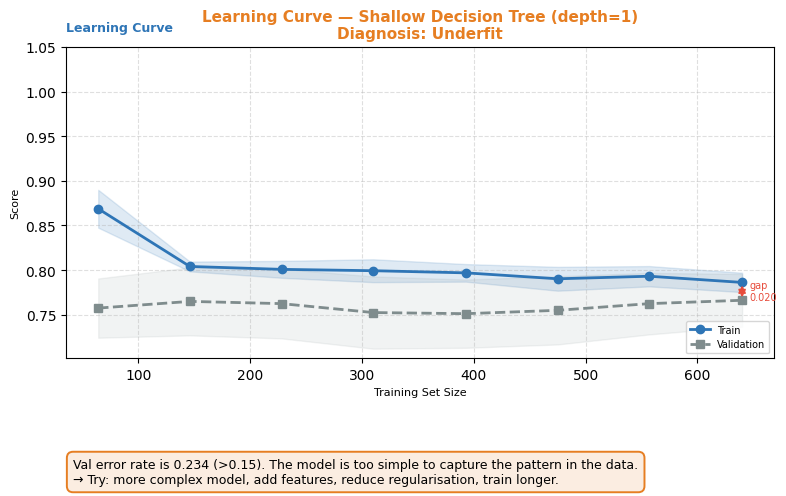

In [18]:
# --- Underfitting model: very shallow tree ---
underfit_model = DecisionTreeClassifier(max_depth=1, random_state=42)
underfit_model.fit(X_train, y_train)

print("=== Underfitting Model ===")
ev.bias_variance(underfit_model, X_train, y_train, model_name="Shallow Decision Tree (depth=1)")

---
## 5 · Multi-Model Comparison

Pass a `dict` of `{name: fitted_model}` to any comparison function.

First, let's train all four models:

In [19]:
models = {
    "Random Forest":      RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42).fit(X_train, y_train),
}

for name, model in models.items():
    print(f"{name:<25} test acc = {model.score(X_test, y_test):.4f}")

Random Forest             test acc = 0.9100
Logistic Regression       test acc = 0.7750
Decision Tree             test acc = 0.8200
Gradient Boosting         test acc = 0.8800


### 5.1 · `ev.compare_metrics()` — side-by-side metrics table

Prints a comparison table with a **winner per metric** and an overall recommendation.  
Returns a DataFrame-like `Result` you can query directly.

```
ev.compare_metrics(models, X_test, y_test, *, verbose)  →  Result
```

In [20]:
df = ev.compare_metrics(models, X_test, y_test)


  Model Comparison
  Model                   Accuracy        F1 Precision    Recall   ROC-AUC
  ──────────────────────────────────────────────────────────────
  Random Forest             0.9100    0.9109    0.9020    0.9200    0.9390
  Logistic Regression       0.7750    0.7887    0.7434    0.8400    0.8571
  Decision Tree             0.8200    0.8252    0.8019    0.8500    0.8664
  Gradient Boosting         0.8800    0.8846    0.8519    0.9200    0.9304

  Winners by metric:
    Accuracy     → Random Forest  (0.9100)
    F1           → Random Forest  (0.9109)
    Precision    → Random Forest  (0.9020)
    Recall       → Random Forest  (0.9200)
    ROC-AUC      → Random Forest  (0.9390)

  ✅  Overall recommendation: Random Forest
      (weighted score — F1 & Recall weighted highest)



In [21]:
# Query the Result like a DataFrame
print("Best F1     :", df["F1"].idxmax())
print("Best ROC-AUC:", df["ROC-AUC"].idxmax())
print("Best Accuracy:", df["Accuracy"].idxmax())

Best F1     : Random Forest
Best ROC-AUC: Random Forest
Best Accuracy: Random Forest


### 5.2 · `ev.compare_interpret()` — plain-English per model

```
ev.compare_interpret(models, X_test, y_test)  →  Result  {name: text}
```

In [22]:
interps = ev.compare_interpret(models, X_test, y_test)


  ── Random Forest ──
     ✅  Accuracy 0.910 — high overall correctness.
     ✅  F1 0.911 — strong balance between precision and recall.
     ✅  Precision (0.902) ≈ Recall (0.920) — well balanced.
          AUC = 0.939 — Good. Works well but there is room to improve.

  ── Logistic Regression ──
     ⚠️   Accuracy 0.775 — acceptable but worth improving.
     ⚠️   F1 0.789 — moderate. Consider threshold tuning.
     ✅  Precision (0.743) ≈ Recall (0.840) — well balanced.
          AUC = 0.857 — Good. Works well but there is room to improve.

  ── Decision Tree ──
     ⚠️   Accuracy 0.820 — acceptable but worth improving.
     ⚠️   F1 0.825 — moderate. Consider threshold tuning.
     ✅  Precision (0.802) ≈ Recall (0.850) — well balanced.
          AUC = 0.866 — Good. Works well but there is room to improve.

  ── Gradient Boosting ──
     ⚠️   Accuracy 0.880 — acceptable but worth improving.
     ✅  F1 0.885 — strong balance between precision and recall.
     ✅  Precision (0.852) ≈ Recal

### 5.3 · `ev.plot_confusion_matrices()` — one subplot per model

```
ev.plot_confusion_matrices(models, X_test, y_test, *, class_labels, colors, figsize, save_path)
→ None
```

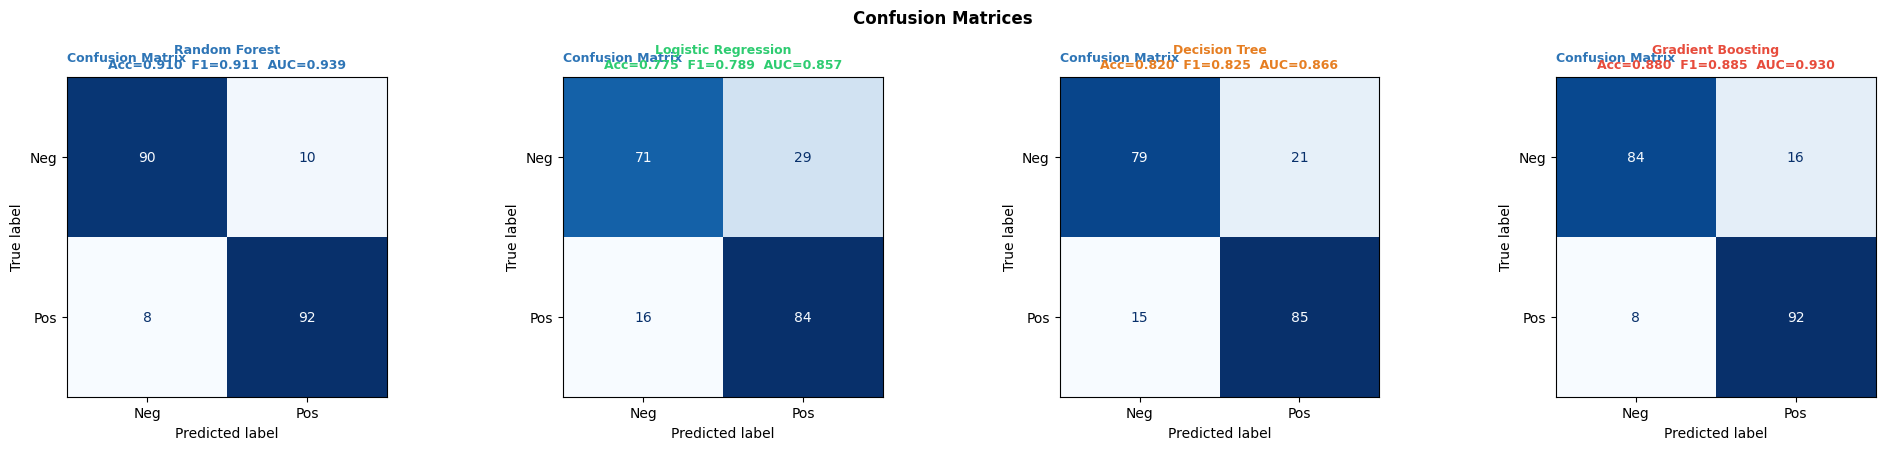

In [23]:
ev.plot_confusion_matrices(
    models, X_test, y_test,
    class_labels=["Neg", "Pos"]
)

### 5.4 · `ev.compare_roc_curves()` — overlaid ROC curves

All models on one axes. AUC grades are printed to the terminal.

```
ev.compare_roc_curves(models, X_test, y_test, *, colors, figsize, save_path)
→ None
```


  ROC-AUC Scores
  ──────────────────────────────────────
  Random Forest              AUC = 0.9390  Good
  Logistic Regression        AUC = 0.8571  Good
  Decision Tree              AUC = 0.8663  Good
  Gradient Boosting          AUC = 0.9304  Good


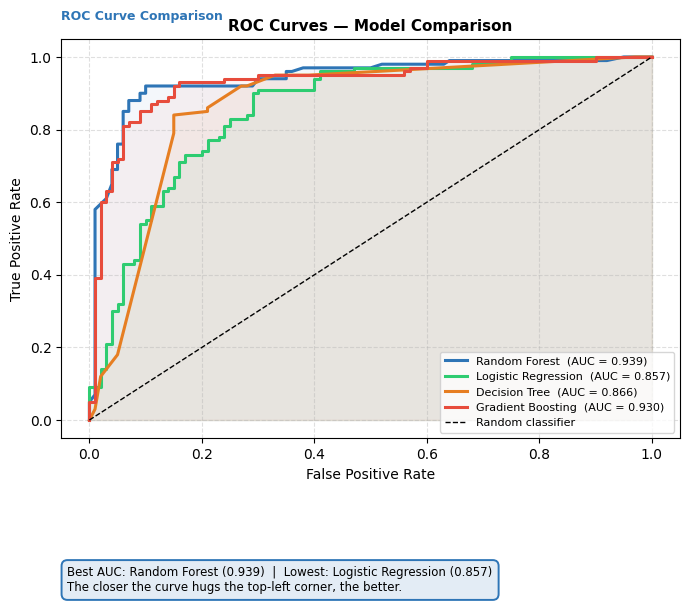

In [24]:
ev.compare_roc_curves(models, X_test, y_test)

### 5.5 · `ev.plot_metrics_comparison()` — grouped bar chart

Accuracy, F1, Precision, Recall, ROC-AUC across all models as grouped bars.

```
ev.plot_metrics_comparison(models, X_test, y_test, *, colors, figsize, save_path)
→ None
```

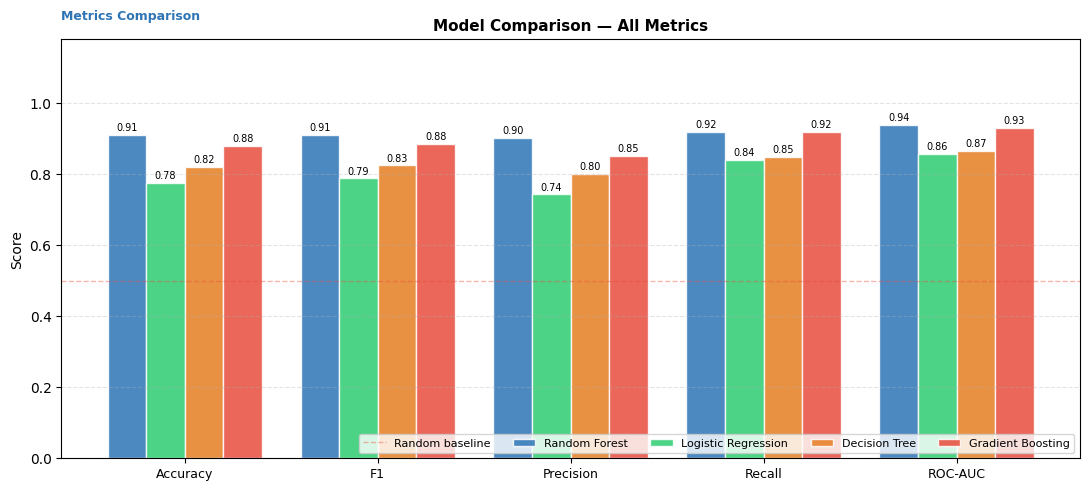

In [25]:
ev.plot_metrics_comparison(models, X_test, y_test)

### 5.6 · `ev.comparison_dashboard()` — full 3-row dashboard

The all-in-one multi-model view:

```
Row 1 ── Confusion matrix per model
Row 2 ── Overlaid ROC curves  +  Grouped metrics bar chart
Row 3 ── Colour-coded summary table (green = top, red = bottom)
```

Also prints metrics + winner summary to the terminal.

```
ev.comparison_dashboard(models, X_test, y_test, *, class_labels, colors, figsize, save_path)
→ None
```


  Model Comparison
  Model                   Accuracy        F1 Precision    Recall   ROC-AUC
  ──────────────────────────────────────────────────────────────
  Random Forest             0.9100    0.9109    0.9020    0.9200    0.9390
  Logistic Regression       0.7750    0.7887    0.7434    0.8400    0.8571
  Decision Tree             0.8200    0.8252    0.8019    0.8500    0.8664
  Gradient Boosting         0.8800    0.8846    0.8519    0.9200    0.9304

  Winners by metric:
    Accuracy     → Random Forest  (0.9100)
    F1           → Random Forest  (0.9109)
    Precision    → Random Forest  (0.9020)
    Recall       → Random Forest  (0.9200)
    ROC-AUC      → Random Forest  (0.9390)

  ✅  Overall recommendation: Random Forest
      (weighted score — F1 & Recall weighted highest)



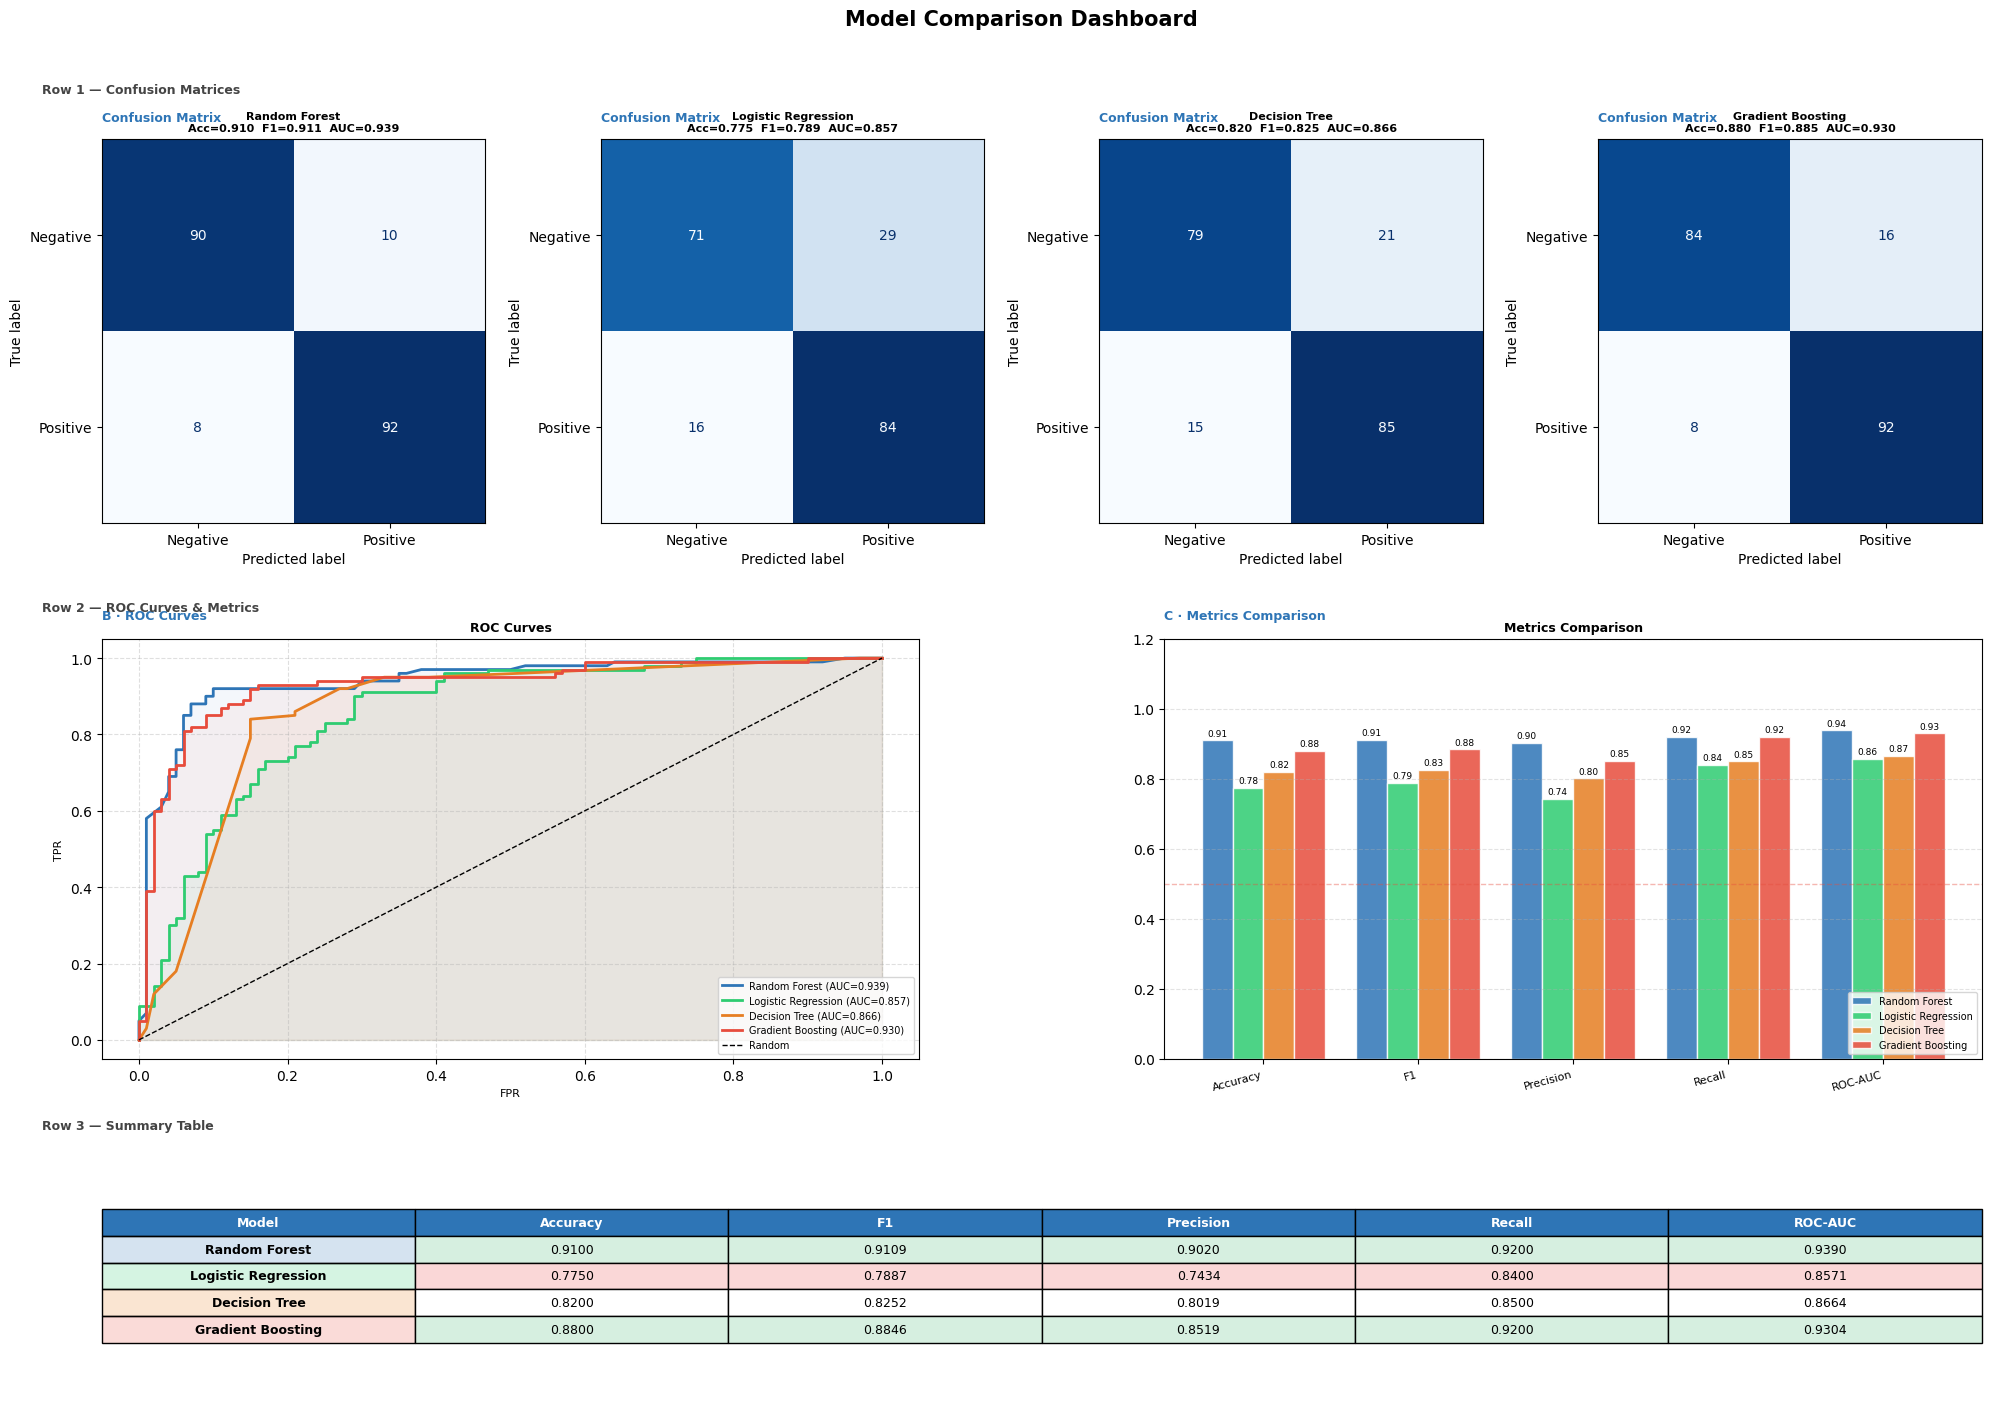

In [26]:
ev.comparison_dashboard(
    models, X_test, y_test,
    class_labels=["Negative", "Positive"]
)

### 5.7 · `ev.compare_bias_variance()` — multi-model B-V dashboard

Two-row Bias–Variance dashboard for all models. Returns a **nested Result**.

```
Row 1 ── Learning curve per model with diagnosis label
Row 2 ── Bias proxy · Variance proxy · Overfitting gap
```

```
ev.compare_bias_variance(models, X_train, y_train, *, n_splits, overfit_threshold, ...)
→ Result  (nested: cb["ModelName"]["diagnosis"])
```

  Bias–Variance Analysis

  🔴 Random Forest
     Train Acc : 1.0000
     Val   Acc : 0.8662
     Gap       : 0.1338   (threshold: 0.1)
     Val Std   : 0.0239   (variance proxy)
     Diagnosis : Overfit
     Train–val gap is 0.134 (>0.1). The model memorises training data but fails to generalise.
→ Try: regularisation, reduce model complexity, more training data, dropout.

  ⚠️  Logistic Regression
     Train Acc : 0.8056
     Val   Acc : 0.8037
     Gap       : 0.0019   (threshold: 0.1)
     Val Std   : 0.0366   (variance proxy)
     Diagnosis : Underfit
     Val error rate is 0.196 (>0.15). The model is too simple to capture the pattern in the data.
→ Try: more complex model, add features, reduce regularisation, train longer.

  ⚠️  Decision Tree
     Train Acc : 0.8878
     Val   Acc : 0.8037
     Gap       : 0.0841   (threshold: 0.1)
     Val Std   : 0.0332   (variance proxy)
     Diagnosis : Underfit
     Val error rate is 0.196 (>0.15). The model is too simple to capture the patt

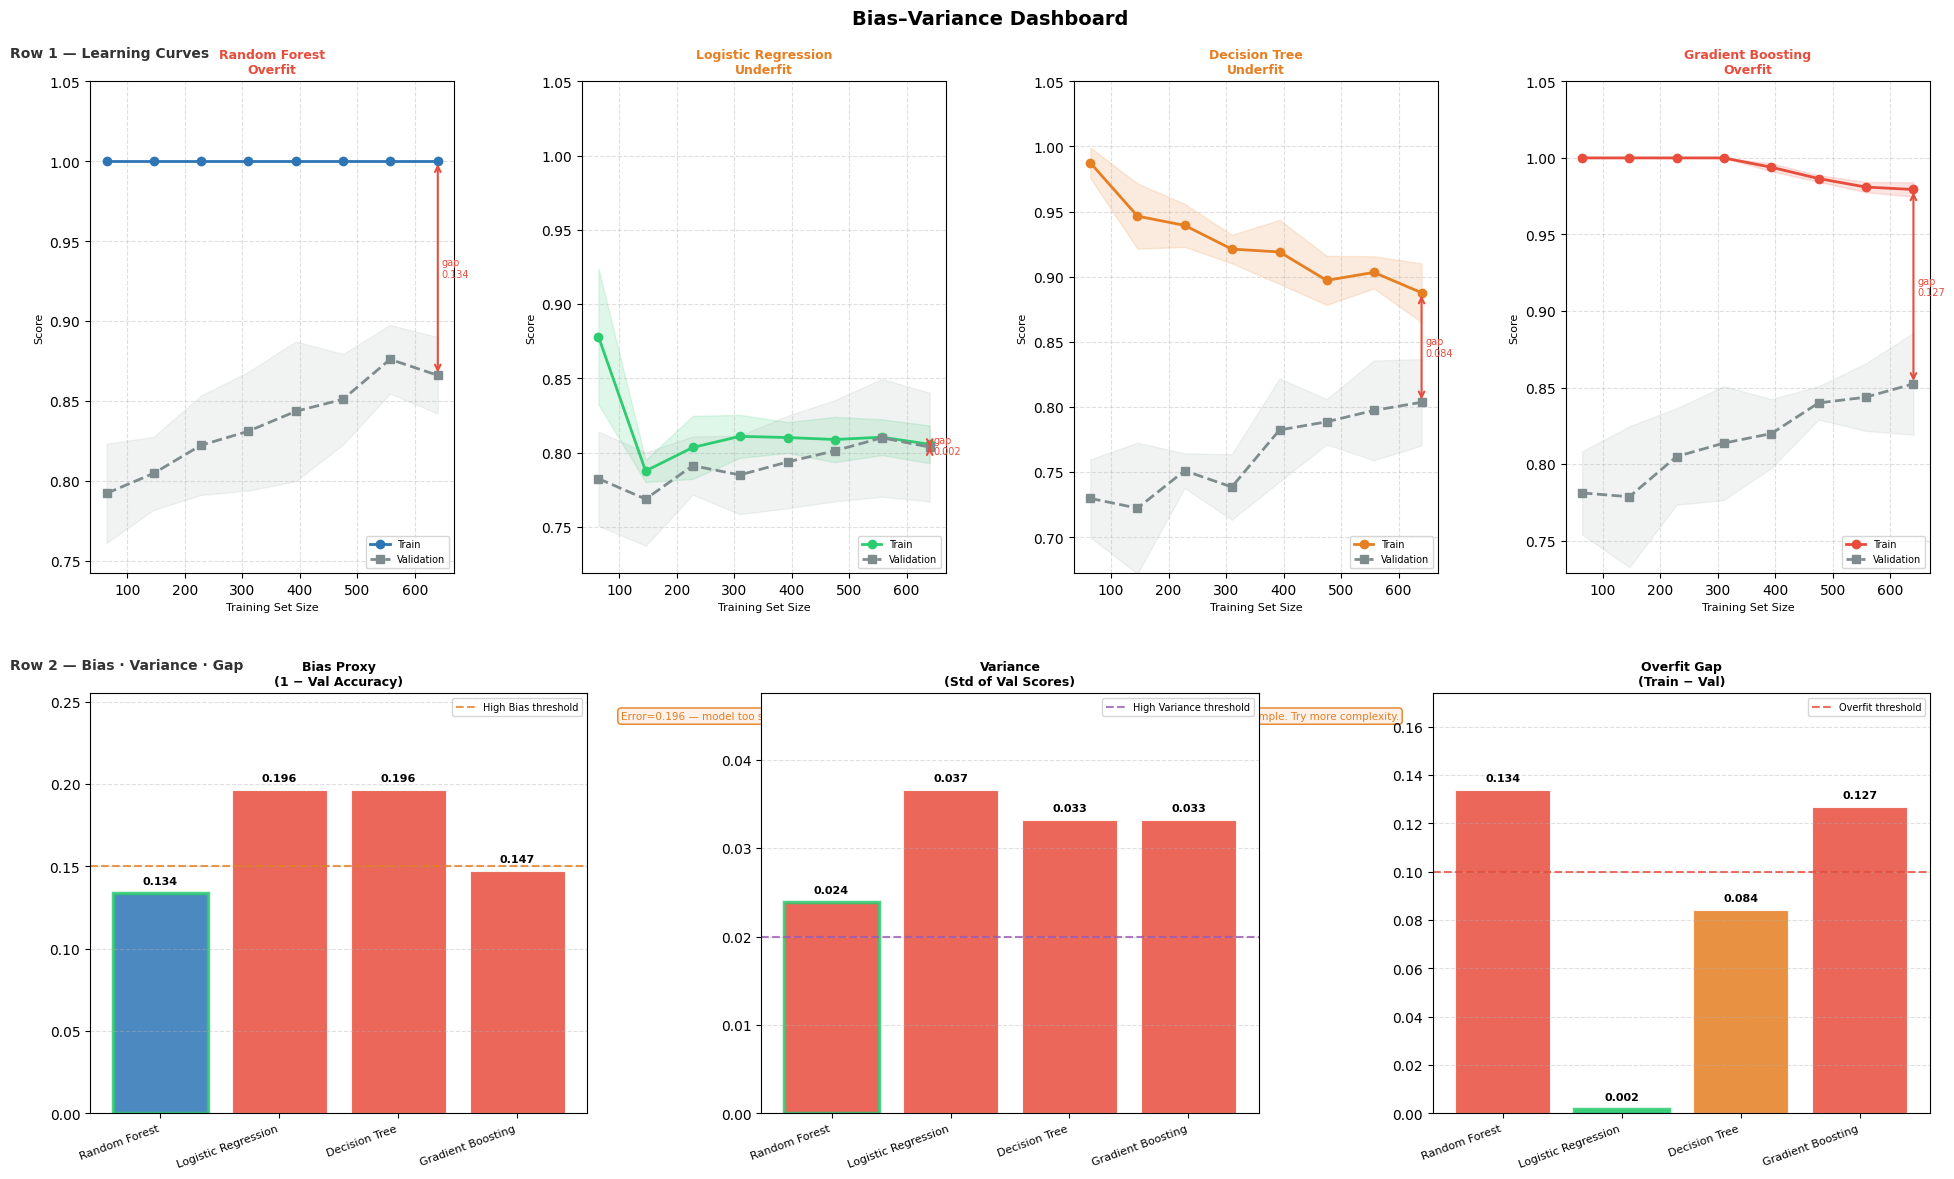

In [27]:
cb = ev.compare_bias_variance(models, X_train, y_train)

In [28]:
# Access nested results
print("\n── Bias–Variance Summary ──")
for model_name, result in cb.items():
    print(f"  {model_name:<25} diagnosis={result['diagnosis']:<12}  gap={result['gap']:.4f}")


── Bias–Variance Summary ──
  Random Forest             diagnosis=Overfit       gap=0.1338
  Logistic Regression       diagnosis=Underfit      gap=0.0019
  Decision Tree             diagnosis=Underfit      gap=0.0841
  Gradient Boosting         diagnosis=Overfit       gap=0.1269


---
## 6 · The Result Object — Deep Dive

Every function that computes data returns a `Result` — a **silent dict-like container** that never auto-displays in Jupyter, keeping your cells clean.

In [29]:
# --- ev.metrics() Result keys ---
m = ev.metrics(rf, X_test, y_test, verbose=False)  # verbose=False suppresses print

print("Keys available:", list(m.keys()))
print()
print("accuracy  :", round(m["accuracy"],  4))
print("f1        :", round(m["f1"],        4))
print("precision :", round(m["precision"], 4))
print("recall    :", round(m["recall"],    4))
print("roc_auc   :", round(m["roc_auc"],  4))
print("y_pred    :", m["y_pred"][:10], "...")
print("y_prob    :", m["y_prob"][:5].round(3), "...")

Keys available: ['y_pred', 'y_prob', 'accuracy', 'f1', 'precision', 'recall', 'roc_auc', 'report']

accuracy  : 0.91
f1        : 0.9109
precision : 0.902
recall    : 0.92
roc_auc   : 0.939
y_pred    : [1 0 0 0 1 1 1 1 0 0] ...
y_prob    : [0.79 0.09 0.02 0.16 0.98] ...


In [30]:
# --- ev.bv_stats() Result keys ---
bv = ev.bv_stats(rf, X_train, y_train, verbose=False)

print("Keys available:", list(bv.keys()))
print()
print("diagnosis  :", bv["diagnosis"])
print("explanation:", bv["explanation"])
print("gap        :", round(bv["gap"], 4))
print("bias_proxy :", round(bv["bias_proxy"], 4))
print("val_std    :", round(bv["val_std"], 4))

Keys available: ['lc_sizes', 'lc_train', 'lc_val', 'mean_train', 'mean_val', 'val_std', 'gap', 'bias_proxy', 'diagnosis', 'diag_color', 'explanation']

diagnosis  : Overfit
explanation: Train–val gap is 0.134 (>0.1). The model memorises training data but fails to generalise.
→ Try: regularisation, reduce model complexity, more training data, dropout.
gap        : 0.1338
bias_proxy : 0.1338
val_std    : 0.0239


In [31]:
# --- ev.compare_metrics() Result — DataFrame-like ---
df = ev.compare_metrics(models, X_test, y_test, verbose=False)

# Query like a pandas DataFrame
print("Best F1      :", df["F1"].idxmax())
print("Best ROC-AUC :", df["ROC-AUC"].idxmax())
print("Best Accuracy:", df["Accuracy"].idxmax())
print()
print(df)

Best F1      : Random Forest
Best ROC-AUC : Random Forest
Best Accuracy: Random Forest




  Bias–Variance Analysis

  🔴 Random Forest
     Train Acc : 1.0000
     Val   Acc : 0.8662
     Gap       : 0.1338   (threshold: 0.1)
     Val Std   : 0.0239   (variance proxy)
     Diagnosis : Overfit
     Train–val gap is 0.134 (>0.1). The model memorises training data but fails to generalise.
→ Try: regularisation, reduce model complexity, more training data, dropout.

  ⚠️  Logistic Regression
     Train Acc : 0.8056
     Val   Acc : 0.8037
     Gap       : 0.0019   (threshold: 0.1)
     Val Std   : 0.0366   (variance proxy)
     Diagnosis : Underfit
     Val error rate is 0.196 (>0.15). The model is too simple to capture the pattern in the data.
→ Try: more complex model, add features, reduce regularisation, train longer.

  ⚠️  Decision Tree
     Train Acc : 0.8878
     Val   Acc : 0.8037
     Gap       : 0.0841   (threshold: 0.1)
     Val Std   : 0.0332   (variance proxy)
     Diagnosis : Underfit
     Val error rate is 0.196 (>0.15). The model is too simple to capture the patt

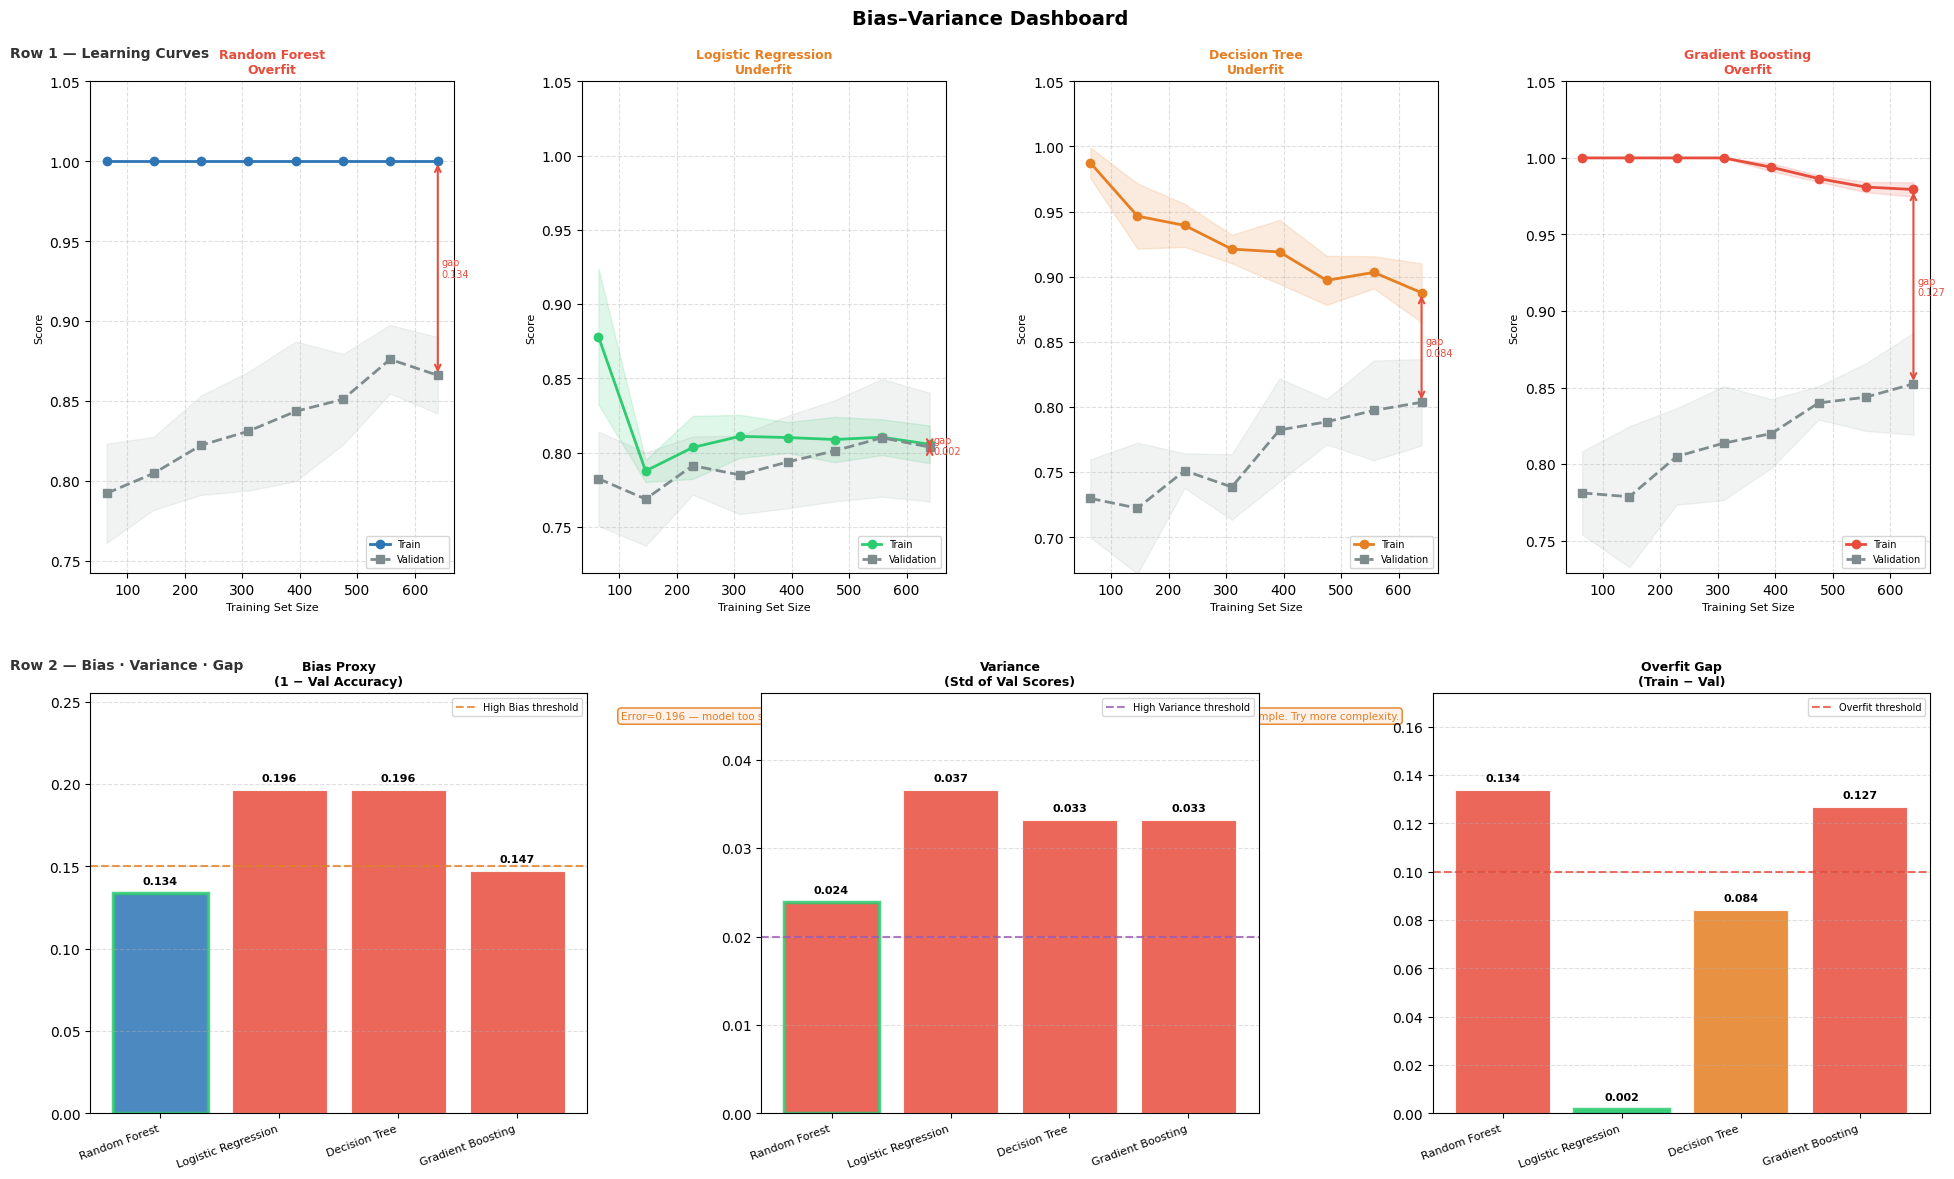

Random Forest:
  diagnosis : Overfit
  gap       : 0.1338

Decision Tree:
  diagnosis : Underfit
  gap       : 0.0841


In [33]:
# --- ev.compare_bias_variance() — nested Result ---
cb = ev.compare_bias_variance(models, X_train, y_train)

# Access any model's sub-result by name
print("Random Forest:")
print("  diagnosis :", cb["Random Forest"]["diagnosis"])
print("  gap       :", round(cb["Random Forest"]["gap"], 4))
print()
print("Decision Tree:")
print("  diagnosis :", cb["Decision Tree"]["diagnosis"])
print("  gap       :", round(cb["Decision Tree"]["gap"], 4))

---
## 7 · Saving Figures to Disk

Every plot function accepts an optional `save_path` argument. Pass a file path and the figure is saved automatically — PNG, PDF, SVG, etc.


  Model Summary — Random Forest
  Accuracy  : 0.9100
  F1        : 0.9109
  Precision : 0.9020
  Recall    : 0.9200
  ROC-AUC   : 0.9390

  Interpretation — Random Forest
  ─────────────────────────────────────────────────────
  ✅  Accuracy 0.910 — high overall correctness.
  ✅  F1 0.911 — strong balance between precision and recall.
  ✅  Precision (0.902) ≈ Recall (0.920) — well balanced.
       AUC = 0.939 — Good. Works well but there is room to improve.

  Saved → figures/summary.png


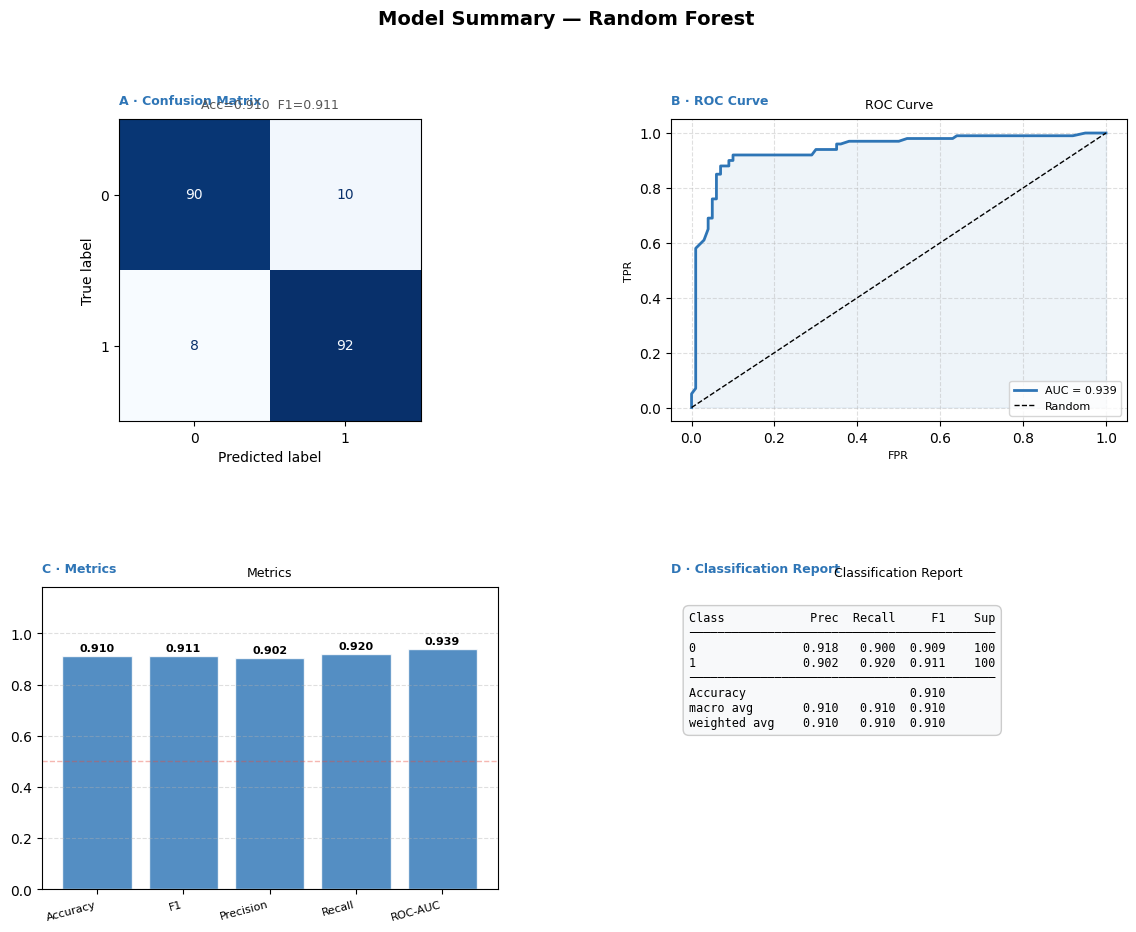


  ROC-AUC (Model): 0.9390
  AUC = 0.939 — Good. Works well but there is room to improve.

  Saved → figures/roc.png


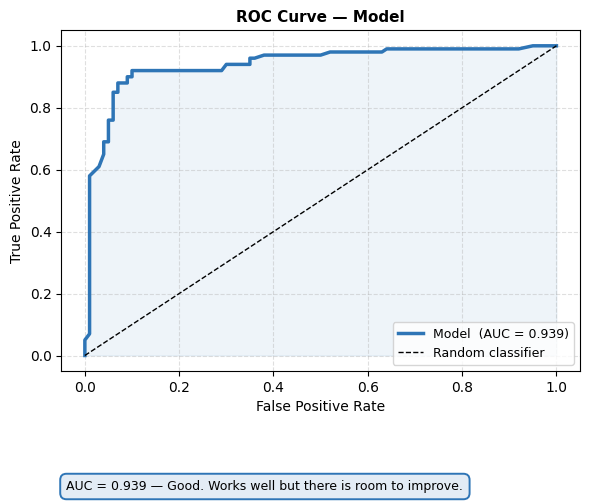

  Saved → figures/learning_curve.png


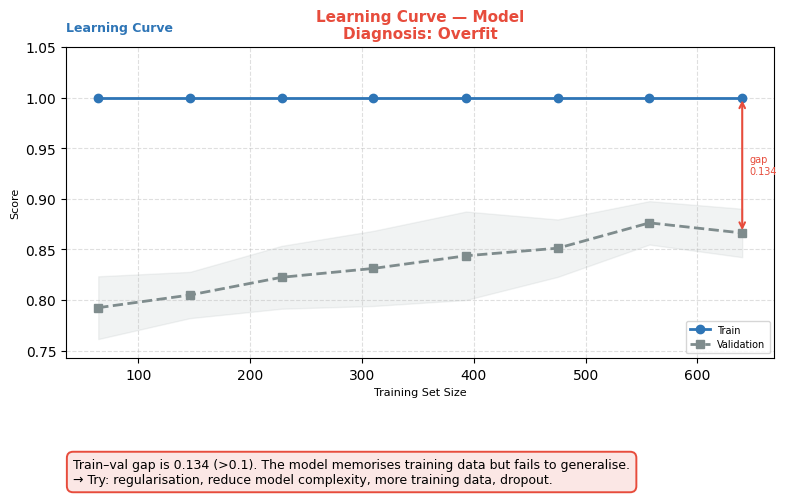


  Model Comparison
  Model                   Accuracy        F1 Precision    Recall   ROC-AUC
  ──────────────────────────────────────────────────────────────
  Random Forest             0.9100    0.9109    0.9020    0.9200    0.9390
  Logistic Regression       0.7750    0.7887    0.7434    0.8400    0.8571
  Decision Tree             0.8200    0.8252    0.8019    0.8500    0.8664
  Gradient Boosting         0.8800    0.8846    0.8519    0.9200    0.9304

  Winners by metric:
    Accuracy     → Random Forest  (0.9100)
    F1           → Random Forest  (0.9109)
    Precision    → Random Forest  (0.9020)
    Recall       → Random Forest  (0.9200)
    ROC-AUC      → Random Forest  (0.9390)

  ✅  Overall recommendation: Random Forest
      (weighted score — F1 & Recall weighted highest)


  Saved → figures/comparison_dashboard.png


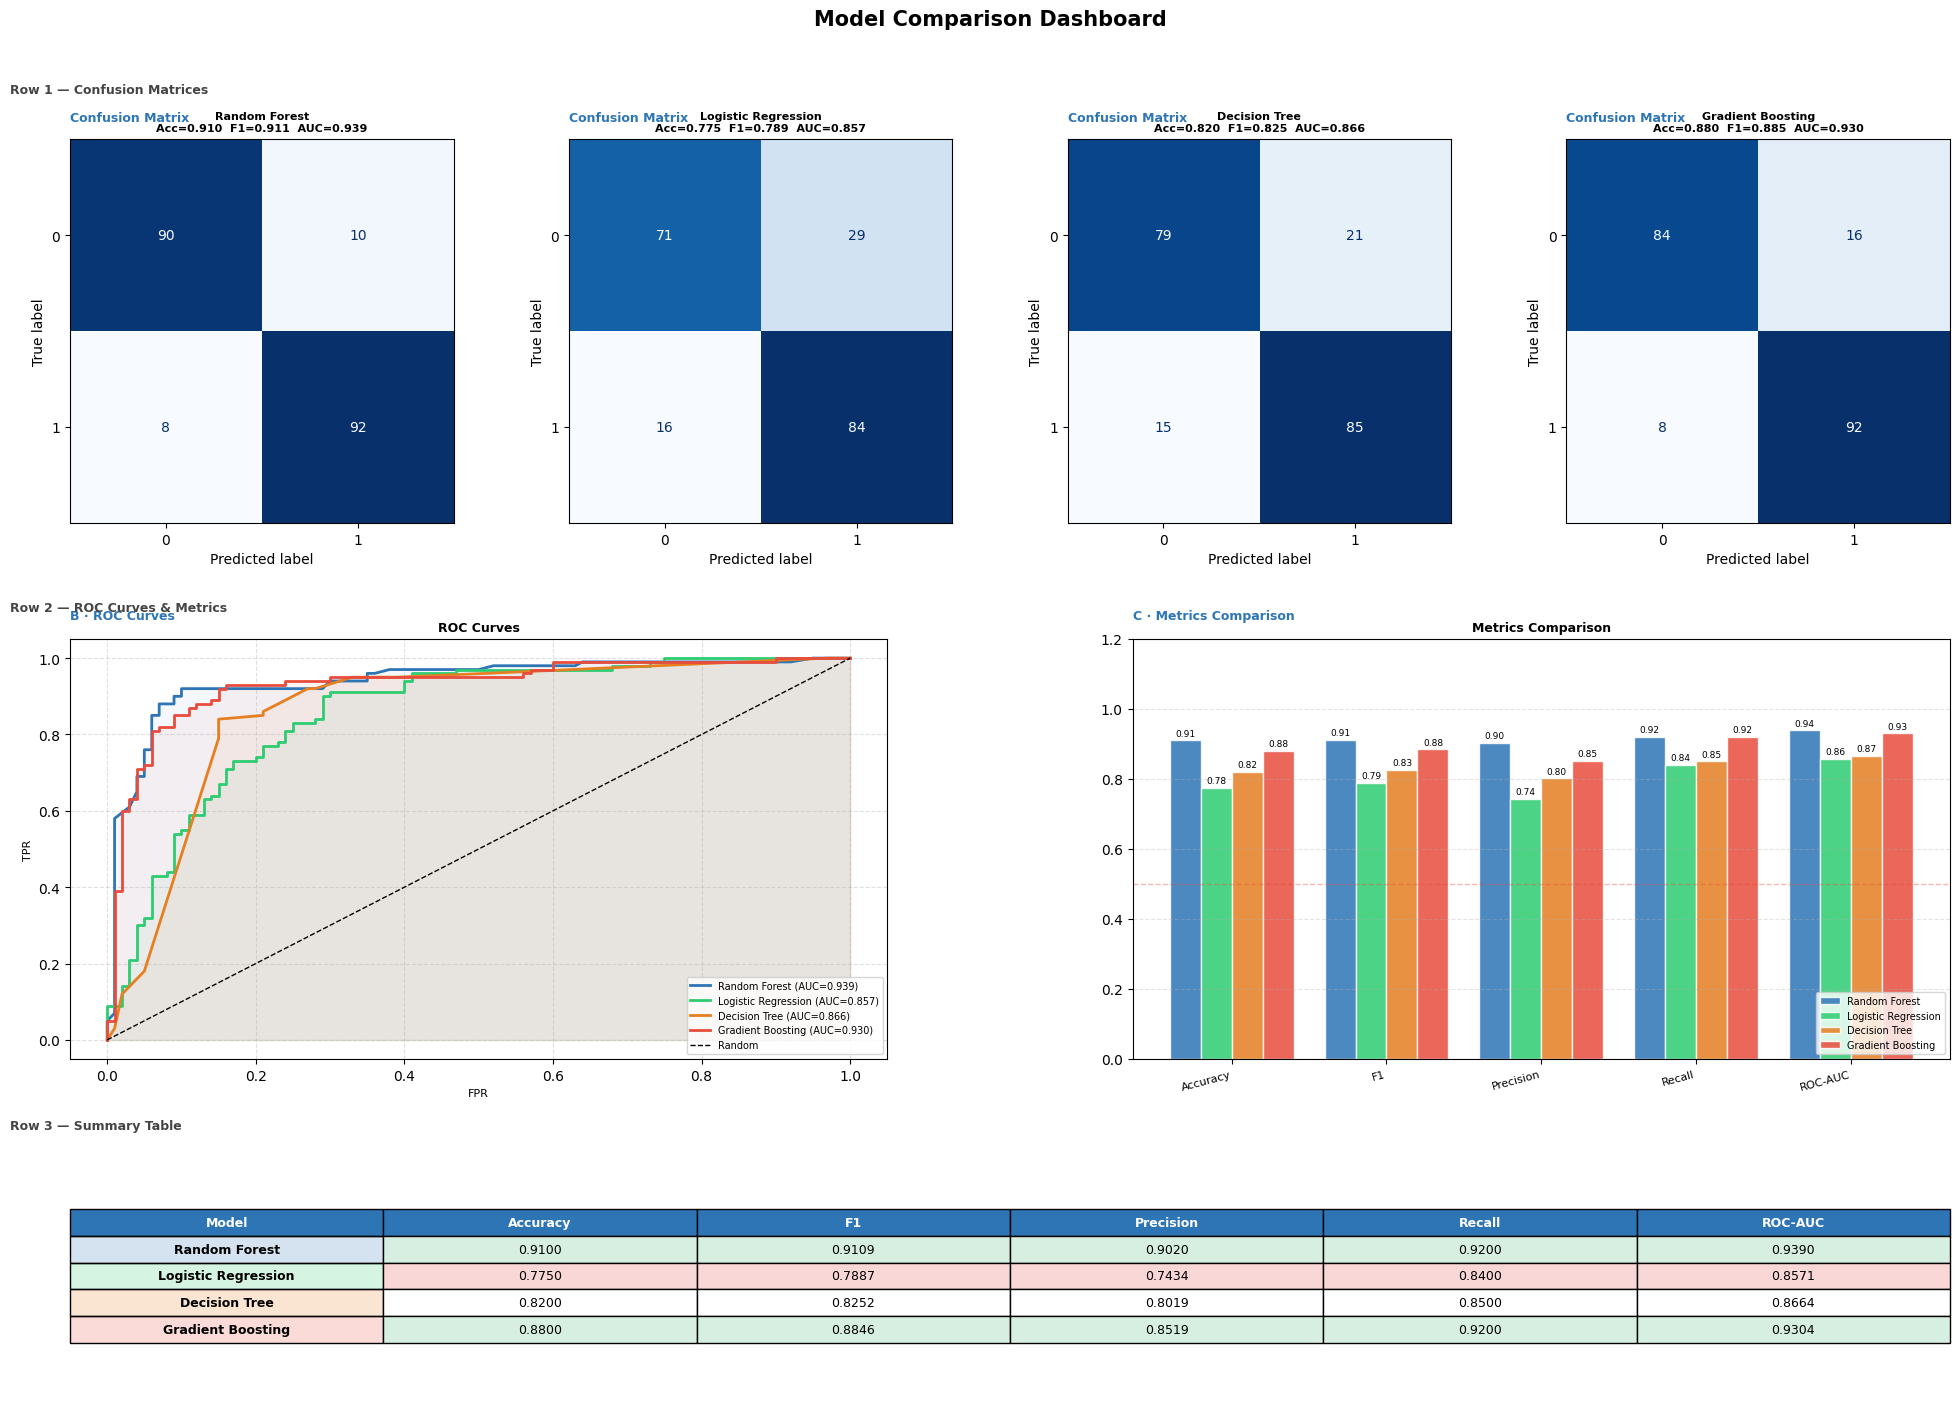

  Bias–Variance Analysis

  🔴 Random Forest
     Train Acc : 1.0000
     Val   Acc : 0.8662
     Gap       : 0.1338   (threshold: 0.1)
     Val Std   : 0.0239   (variance proxy)
     Diagnosis : Overfit
     Train–val gap is 0.134 (>0.1). The model memorises training data but fails to generalise.
→ Try: regularisation, reduce model complexity, more training data, dropout.

  ⚠️  Logistic Regression
     Train Acc : 0.8056
     Val   Acc : 0.8037
     Gap       : 0.0019   (threshold: 0.1)
     Val Std   : 0.0366   (variance proxy)
     Diagnosis : Underfit
     Val error rate is 0.196 (>0.15). The model is too simple to capture the pattern in the data.
→ Try: more complex model, add features, reduce regularisation, train longer.

  ⚠️  Decision Tree
     Train Acc : 0.8878
     Val   Acc : 0.8037
     Gap       : 0.0841   (threshold: 0.1)
     Val Std   : 0.0332   (variance proxy)
     Diagnosis : Underfit
     Val error rate is 0.196 (>0.15). The model is too simple to capture the patt

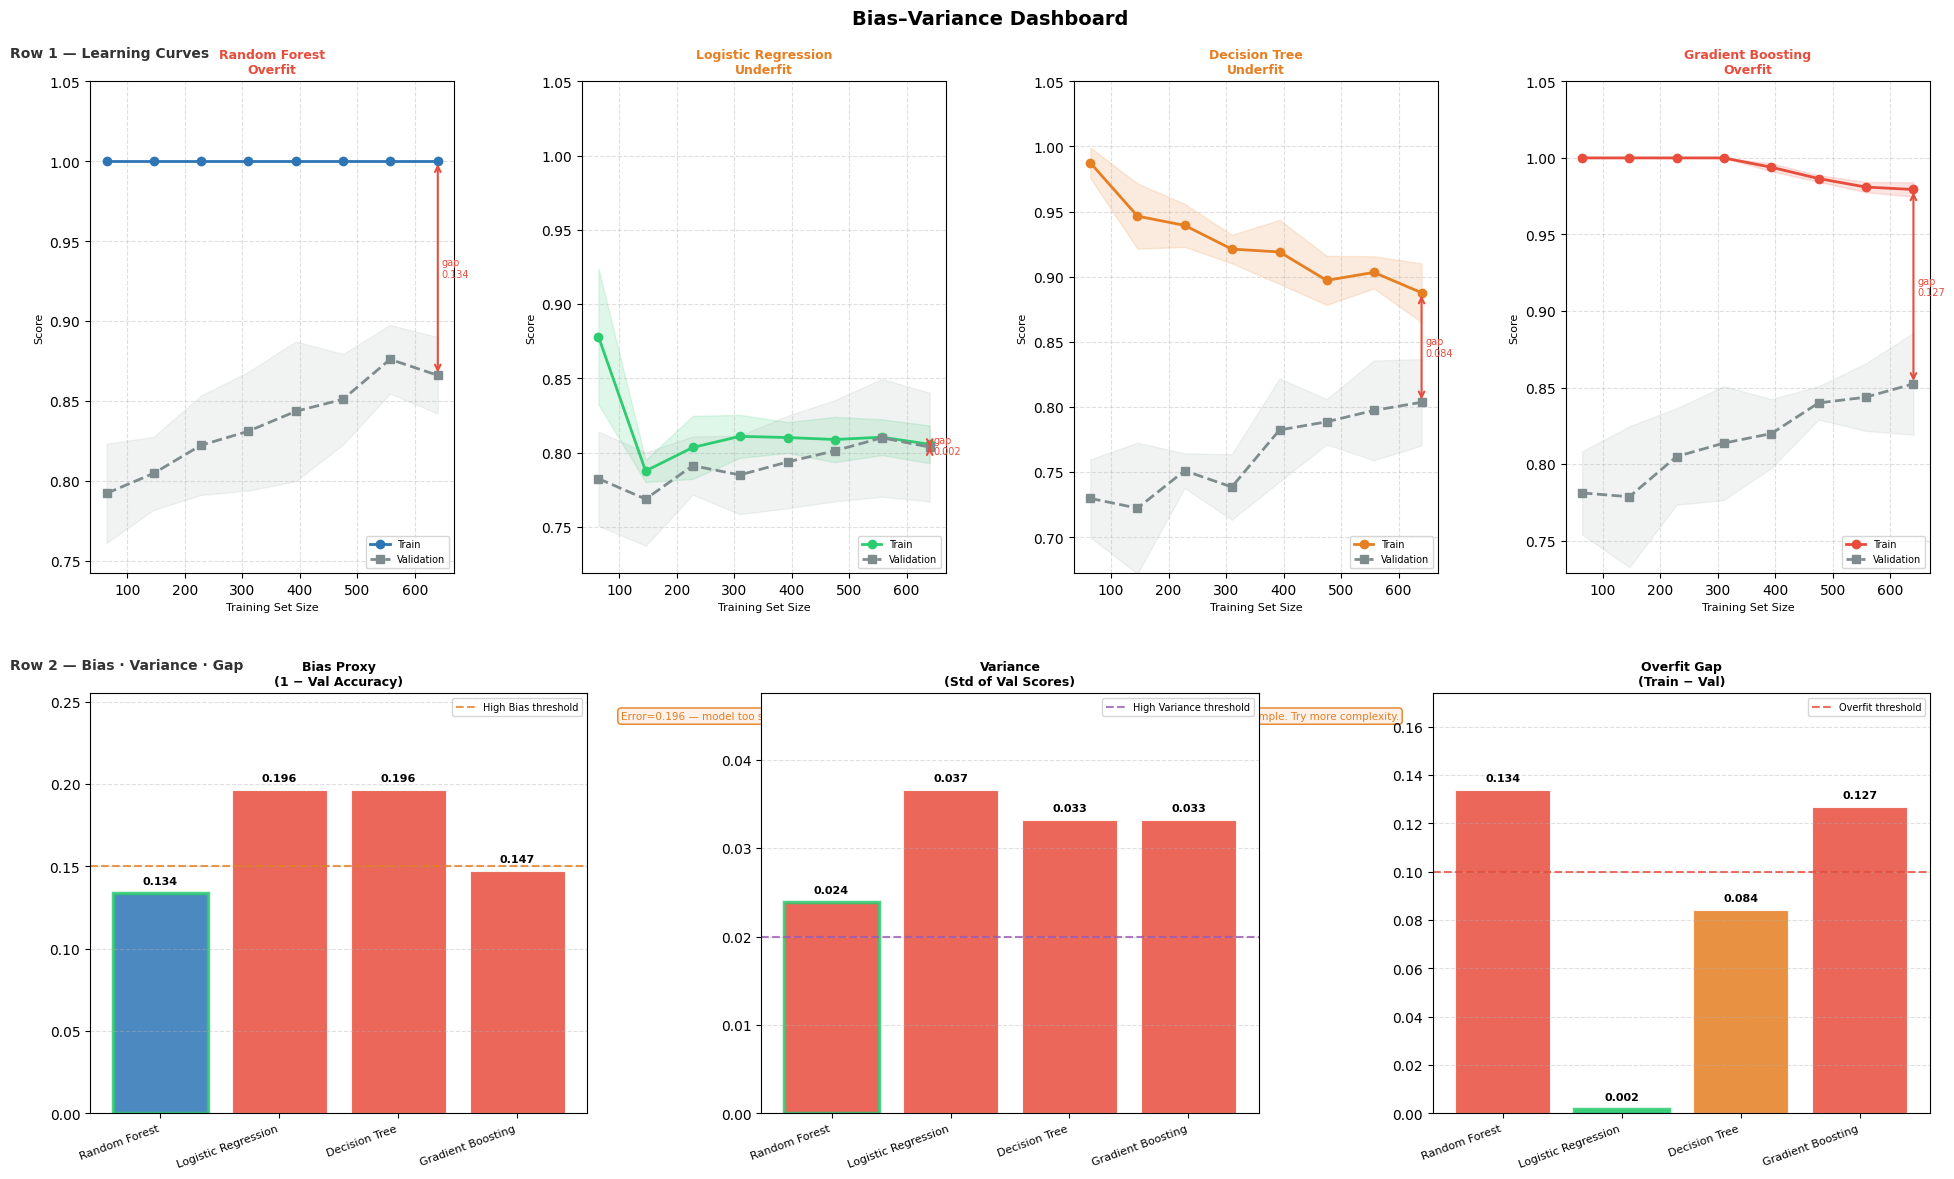


✅ All figures saved to ./figures/
['roc.png', 'learning_curve.png', 'comparison_dashboard.png', 'bv_compare.png', 'summary.png']


In [34]:
import os
os.makedirs("figures", exist_ok=True)

# ── Single-model figures ──────────────────────────────────────────────
ev.model_summary(
    rf, X_test, y_test,
    model_name="Random Forest",
    save_path="figures/summary.png"
)

ev.plot_roc_curve(
    rf, X_test, y_test,
    save_path="figures/roc.png"
)

ev.plot_learning_curve(
    rf, X_train, y_train,
    save_path="figures/learning_curve.png"
)

# ── Multi-model figures ───────────────────────────────────────────────
ev.comparison_dashboard(
    models, X_test, y_test,
    save_path="figures/comparison_dashboard.png"
)

ev.compare_bias_variance(
    models, X_train, y_train,
    save_path="figures/bv_compare.png"
)

print("\n✅ All figures saved to ./figures/")
print(os.listdir("figures"))

---
## 8 · Quick Reference Card

### Single-Model
| Function | Output | Returns |
|----------|--------|--------|
| `ev.metrics(model, X_test, y_test)` | Metrics table printed | `Result` |
| `ev.interpret(model, X_test, y_test)` | Plain-English text | `Result` |
| `ev.classification_report(model, ...)` | Per-class table | `None` |
| `ev.plot_confusion_matrix(model, ...)` | Confusion matrix figure | `None` |
| `ev.plot_roc_curve(model, ...)` | ROC + AUC grade | `None` |
| `ev.plot_metrics_bar(model, ...)` | Bar chart + baseline | `None` |
| `ev.model_summary(model, ...)` | **2×2 full dashboard** | `None` |

### Bias–Variance
| Function | Output | Returns |
|----------|--------|--------|
| `ev.bv_stats(model, X_train, y_train)` | Stats + diagnosis | `Result` |
| `ev.plot_learning_curve(model, ...)` | Learning curve figure | `None` |
| `ev.bias_variance(model, ...)` | Stats + figure | `Result` |

### Multi-Model  *(pass `models = {"name": fitted_model, ...}`)*
| Function | Output | Returns |
|----------|--------|--------|
| `ev.compare_metrics(models, ...)` | Metrics table + winner | `Result` (DataFrame-like) |
| `ev.compare_interpret(models, ...)` | Text per model | `Result` |
| `ev.plot_confusion_matrices(models, ...)` | Subplots row | `None` |
| `ev.compare_roc_curves(models, ...)` | Overlaid ROC | `None` |
| `ev.plot_metrics_comparison(models, ...)` | Grouped bar chart | `None` |
| `ev.comparison_dashboard(models, ...)` | **3-row full dashboard** | `None` |
| `ev.compare_bias_variance(models, ...)` | **2-row B-V dashboard** | `Result` (nested) |